#**FOG OF CRISIS: EXECUTIVE COMMUNICATION COMPLEXITY DURING COVID-19**

**Research Question:** Did COVID-19 drive executives to adopt more complex
communication styles, and did this vary by industry vulnerability?

Author: Sadia Kiran, Ajeyaa Sinha Roy, Danish Ahmad

Date: January 2026

In [1]:
!pip install linearmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set professional styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

print("="*80)
print("THE FOG OF CRISIS - EXECUTIVE COMMUNICATION COMPLEXITY ANALYSIS")
print("="*80)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.1 MB/s eta 0:00:00
THE FOG OF CRISIS - EXECUTIVE COMMUNICATION COMPLEXITY ANALYSIS


In [2]:
df = pd.read_parquet("youtube_data_anonymized.parquet")
print(f"✓ Loaded {len(df):,} observations")
df['publish_date'] = pd.to_datetime(df['publish_date'], utc=True)
print(f"✓ Date range: {df['publish_date'].min()} to {df['publish_date'].max()}")
print(f"✓ Number of unique companies: {df['gvkey'].nunique():,}")
print(f"✓ Number of unique executives: {df['exec_fullname'].nunique():,}")

✓ Loaded 24,255 observations
✓ Date range: 2007-02-07 20:58:32+00:00 to 2025-06-02 14:30:41+00:00
✓ Number of unique companies: 1,106
✓ Number of unique executives: 2,259


**Date Processing**

In [3]:
df["year"] = df["publish_date"].dt.year
df["month"] = df["publish_date"].dt.month
df["quarter"] = df["publish_date"].dt.to_period("Q")
df["year_month"] = df["publish_date"].dt.to_period("M")
df["covid"] = (df["publish_date"] >= "2020-03-01").astype(int)
df["pre_covid"] = (df["publish_date"] < "2020-03-01").astype(int)
def calculate_quarters_to_covid(date):
    if pd.isna(date):
        return np.nan
    year = date.year
    quarter = (date.month - 1) // 3 + 1
    quarters_since_2020 = (year - 2020) * 4 + (quarter - 1)
    return quarters_since_2020
df["quarters_to_covid"] = df["publish_date"].apply(calculate_quarters_to_covid)
print(f"✓ COVID period starts: March 1, 2020")
print(f"✓ Pre-COVID observations: {df['pre_covid'].sum():,}")
print(f"✓ Post-COVID observations: {df['covid'].sum():,}")
print(f"✓ quarters_to_covid range: {df['quarters_to_covid'].min():.0f} to {df['quarters_to_covid'].max():.0f}")

✓ COVID period starts: March 1, 2020
✓ Pre-COVID observations: 11,208
✓ Post-COVID observations: 13,000
✓ quarters_to_covid range: -52 to 21


**Video Duration Processing**

In [4]:
def duration_to_seconds(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    parts = s.split(":")
    if len(parts) == 1:
        return pd.to_numeric(s, errors="coerce")
    try:
        parts = [int(p) for p in parts]
    except:
        return np.nan
    if len(parts) == 2:
        return parts[0] * 60 + parts[1]
    elif len(parts) == 3:
        return parts[0] * 3600 + parts[1] * 60 + parts[2]
    return np.nan
df["video_duration_sec"] = df["video_duration"].apply(duration_to_seconds)
df["log_duration"] = np.log1p(df["video_duration_sec"])
print(f"✓ Processed video duration (mean: {df['video_duration_sec'].mean()/60:.1f} minutes)")

✓ Processed video duration (mean: 12.2 minutes)


**View Counts Processing**

In [5]:
df["view_count_num"] = pd.to_numeric(
    df["view_count"].astype(str).str.replace(" views", "").str.replace(",", ""),
    errors="coerce")
df["log_views"] = np.log1p(df["view_count_num"])
print(f"✓ Processed view counts (median: {df['view_count_num'].median():,.0f})")

✓ Processed view counts (median: 2,702)


**Sentiment and Textual Ratios**

In [6]:
df["total_words"] = pd.to_numeric(df["numerosity_total_words"], errors="coerce")
df.loc[df["total_words"] == 0, "total_words"] = np.nan
df["neg_ratio"] = df["negative_word_count_executive"] / df["total_words"]
df["pos_ratio"] = df["positive_word_count_executive"] / df["total_words"]
df["uncert_ratio"] = df["uncertainty_word_count_executive"] / df["total_words"]
df["litig_ratio"] = df["litigious_word_count_executive"] / df["total_words"]
df["constr_ratio"] = df["constraining_word_count_executive"] / df["total_words"]
df["strong_modal_ratio"] = df["strong_modal_word_count_executive"] / df["total_words"]
df["weak_modal_ratio"] = df["weak_modal_word_count_executive"] / df["total_words"]
df["net_sentiment"] = df["pos_ratio"] - df["neg_ratio"]
print(f"✓ Created 8 sentiment/textual ratio variables")

✓ Created 8 sentiment/textual ratio variables


**Readability and Complexity Metrics**

In [7]:
fog_p01 = df["fog_index"].quantile(0.01)
fog_p99 = df["fog_index"].quantile(0.99)
df["fog_index_winsor"] = df["fog_index"].clip(lower=fog_p01, upper=fog_p99)
df["log_sentence_length"] = np.log1p(df["avg_sentence_length"])
print(f"✓ Fog Index range (raw): {df['fog_index'].min():.2f} - {df['fog_index'].max():.2f}")
print(f"✓ Fog Index range (winsorized): {df['fog_index_winsor'].min():.2f} - {df['fog_index_winsor'].max():.2f}")

✓ Fog Index range (raw): 2.90 - 48.56
✓ Fog Index range (winsorized): 6.03 - 17.08


**Industry Classification**

In [8]:
high_exposure_strict = [20.0, 25.0, 60.0]
high_exposure_moderate = [10.0, 15.0, 20.0, 25.0, 60.0]
low_exposure_sectors = [35.0, 45.0, 55.0]
df["high_exposure_strict"] = df["gsector"].isin(high_exposure_strict).astype(int)
df["high_exposure_moderate"] = df["gsector"].isin(high_exposure_moderate).astype(int)
df["low_exposure"] = df["gsector"].isin(low_exposure_sectors).astype(int)
sector_names = {
    10.0: "Energy",
    15.0: "Materials",
    20.0: "Industrials",
    25.0: "Consumer Discretionary",
    30.0: "Consumer Staples",
    35.0: "Health Care",
    40.0: "Financials",
    45.0: "Information Technology",
    50.0: "Communication Services",
    55.0: "Utilities",
    60.0: "Real Estate"}
df["sector_name"] = df["gsector"].map(sector_names)
print("\nSector distribution:")
sector_dist = df.groupby("sector_name").agg({
    "gvkey": "nunique",
    "video_id_anonymized": "count",
    "high_exposure_moderate": "first"
}).rename(columns={"gvkey": "N_Firms", "video_id_anonymized": "N_Videos"})
sector_dist["Exposure"] = sector_dist["high_exposure_moderate"].map({1: "HIGH", 0: "LOW"})
print(sector_dist[["N_Firms", "N_Videos", "Exposure"]].sort_values("N_Videos", ascending=False))


Sector distribution:
                        N_Firms  N_Videos Exposure
sector_name                                       
Information Technology      169      5211      LOW
Consumer Discretionary      206      5050     HIGH
Financials                  151      4354      LOW
Communication Services       61      2747      LOW
Industrials                 152      2644     HIGH
Health Care                 112      1343      LOW
Consumer Staples             68      1304      LOW
Materials                    48       488     HIGH
Energy                       48       451     HIGH
Real Estate                  51       338     HIGH
Utilities                    37       308      LOW


**Simulated Executive Characteristics**

In [9]:
np.random.seed(42)
exec_chars = df.groupby(["exec_fullname", "gvkey"]).agg({
    "year": "min",
    "is_CEO": "max",
    "is_CFO": "max",
    "is_COO": "max",
    "CEO_Duality": "max",
    "Founder_CEO": "max"
}).reset_index()
exec_chars["exec_age_base"] = np.random.normal(55, 8, len(exec_chars)).clip(35, 75)
exec_chars["exec_tenure_base"] = np.random.exponential(5, len(exec_chars)).clip(0, 30)
exec_chars.loc[exec_chars["Founder_CEO"] == 1, "exec_age_base"] += 5
exec_chars.loc[exec_chars["Founder_CEO"] == 1, "exec_tenure_base"] += 8
df = df.merge(exec_chars[["exec_fullname", "gvkey", "exec_age_base", "exec_tenure_base"]],
              on=["exec_fullname", "gvkey"], how="left")
df["exec_age"] = df["exec_age_base"] + (df["year"] - 2018)  # Adjust for year
df["exec_tenure"] = df["exec_tenure_base"] + (df["year"] - 2018)
df["exec_tenure"] = df["exec_tenure"].clip(lower=0)
print(f"✓ Executive age: mean={df['exec_age'].mean():.1f}, std={df['exec_age'].std():.1f}")
print(f"✓ Executive tenure: mean={df['exec_tenure'].mean():.1f}, std={df['exec_tenure'].std():.1f}")

✓ Executive age: mean=57.5, std=8.4
✓ Executive tenure: mean=8.0, std=6.7


**Simulated Company Performance Metrics**

In [10]:
firm_quarters = df[["gvkey", "quarter", "gsector", "high_exposure_moderate"]].drop_duplicates()
firm_quarters["stock_return"] = np.random.normal(0.02, 0.15, len(firm_quarters))
covid_quarters = firm_quarters["quarter"] >= pd.Period("2020Q1", freq="Q")
high_exp = firm_quarters["high_exposure_moderate"] == 1
firm_quarters.loc[covid_quarters & high_exp, "stock_return"] -= 0.15  # -15% shock
firm_quarters["volatility"] = np.random.gamma(2, 0.10, len(firm_quarters))
firm_quarters.loc[covid_quarters, "volatility"] *= 1.8  # Volatility spike
firm_quarters["log_market_cap"] = np.random.normal(8, 2, len(firm_quarters))
firm_quarters["roa"] = np.random.normal(0.05, 0.08, len(firm_quarters))
firm_quarters.loc[covid_quarters & high_exp, "roa"] -= 0.03
df = df.merge(firm_quarters, on=["gvkey", "quarter", "gsector", "high_exposure_moderate"], how="left")
print(f"✓ Stock return: mean={df['stock_return'].mean():.3f}, std={df['stock_return'].std():.3f}")
print(f"✓ Volatility: mean={df['volatility'].mean():.3f}, std={df['volatility'].std():.3f}")
print(f"✓ ROA: mean={df['roa'].mean():.3f}, std={df['roa'].std():.3f}")

✓ Stock return: mean=-0.017, std=0.165
✓ Volatility: mean=0.285, std=0.220
✓ ROA: mean=0.044, std=0.081


**Selecting Analysis Variables**

In [11]:
analysis_vars = [
    "gvkey", "quarter", "year",
    "fog_index", "fog_index_winsor",
    "covid", "pre_covid", "high_exposure_moderate", "gsector", "sector_name",
    "exec_age", "exec_tenure", "is_CEO", "is_CFO", "is_COO",
    "CEO_Duality", "Founder_CEO",
    "neg_ratio", "pos_ratio", "uncert_ratio", "litig_ratio", "constr_ratio",
    "strong_modal_ratio", "weak_modal_ratio", "net_sentiment",
    "log_duration", "log_views", "total_words",
    "stock_return", "volatility", "log_market_cap", "roa",
    "avg_sentence_length", "log_sentence_length", "flesch_reading_ease"]
print(f"✓ Selected {len(analysis_vars)} variables for analysis")

✓ Selected 35 variables for analysis


**Checking Data Quality**

In [12]:
print("\n[5.2] Checking data quality...")
missing_pct = df[analysis_vars].isna().mean().sort_values(ascending=False)
print("\nTop variables with missing data:")
print(missing_pct.head(10))
key_vars = ["fog_index", "gvkey", "quarter", "covid", "gsector"]
df_clean = df.dropna(subset=key_vars).copy()
print(f"\n✓ Observations after dropping missing key vars: {len(df):,} → {len(df_clean):,}")
print(f"  Retention rate: {len(df_clean)/len(df)*100:.1f}%")


[5.2] Checking data quality...

Top variables with missing data:
quarter             0.001938
year                0.001938
exec_age            0.001938
exec_tenure         0.001938
sector_name         0.000701
gsector             0.000701
log_views           0.000247
gvkey               0.000000
pre_covid           0.000000
fog_index_winsor    0.000000
dtype: float64

✓ Observations after dropping missing key vars: 24,255 → 24,191
  Retention rate: 99.7%


**Aggregating to Firm-Quarter Panel**

In [13]:
panel = (
    df_clean
    .groupby(["gvkey", "quarter"], as_index=False)
    .agg(
        fog_index=("fog_index", "mean"),
        fog_index_winsor=("fog_index_winsor", "mean"),
        avg_sentence_length=("avg_sentence_length", "mean"),
        flesch_reading_ease=("flesch_reading_ease", "mean"),
        covid=("covid", "max"),
        year=("year", "first"),
        gsector=("gsector", "first"),
        sector_name=("sector_name", "first"),
        high_exposure=("high_exposure_moderate", "first"),
        exec_age=("exec_age", "mean"),
        exec_tenure=("exec_tenure", "mean"),
        is_CEO=("is_CEO", "max"),
        is_CFO=("is_CFO", "max"),
        CEO_Duality=("CEO_Duality", "max"),
        Founder_CEO=("Founder_CEO", "max"),
        neg_ratio=("neg_ratio", "mean"),
        pos_ratio=("pos_ratio", "mean"),
        uncert_ratio=("uncert_ratio", "mean"),
        litig_ratio=("litig_ratio", "mean"),
        constr_ratio=("constr_ratio", "mean"),
        strong_modal_ratio=("strong_modal_ratio", "mean"),
        weak_modal_ratio=("weak_modal_ratio", "mean"),
        net_sentiment=("net_sentiment", "mean"),
        log_duration=("log_duration", "mean"),
        log_views=("log_views", "mean"),
        total_words=("total_words", "mean"),
        stock_return=("stock_return", "first"),
        volatility=("volatility", "first"),
        log_market_cap=("log_market_cap", "first"),
        roa=("roa", "first"),
        n_interviews=("gvkey", "count")))

print(f"\n✓ Panel dataset created:")
print(f"  Dimensions: {panel.shape}")
print(f"  Firms: {panel['gvkey'].nunique():,}")
print(f"  Quarters: {panel['quarter'].nunique()}")
print(f"  Time span: {panel['quarter'].min()} to {panel['quarter'].max()}")


✓ Panel dataset created:
  Dimensions: (9714, 33)
  Firms: 1,101
  Quarters: 74
  Time span: 2007Q1 to 2025Q2


**Checking Panel Balance**

In [14]:
firm_periods = panel.groupby("gvkey")["covid"].agg(["min", "max", "nunique"])
balanced_firms = firm_periods[firm_periods["nunique"] > 1].index
panel["is_balanced"] = panel["gvkey"].isin(balanced_firms)
print(f"\n✓ Balanced panel analysis:")
print(f"  Firms with both pre/post observations: {len(balanced_firms):,}")
print(f"  Percentage of firms: {len(balanced_firms)/panel['gvkey'].nunique()*100:.1f}%")
print(f"  Observations in balanced panel: {panel['is_balanced'].sum():,}")
panel["covid_x_exposure"] = panel["covid"] * panel["high_exposure"]


✓ Balanced panel analysis:
  Firms with both pre/post observations: 562
  Percentage of firms: 51.0%
  Observations in balanced panel: 8,418


**Summary Statistics by Treatment Group**

In [15]:
summary_vars = ["fog_index", "avg_sentence_length", "flesch_reading_ease",
                "neg_ratio", "pos_ratio", "uncert_ratio",
                "exec_age", "exec_tenure", "stock_return", "volatility"]
summary_stats = panel[summary_vars].describe().T
summary_stats["median"] = panel[summary_vars].median()
summary_stats = summary_stats[["count", "mean", "std", "median", "min", "max"]]
print("\nTable 1: Summary Statistics")
summary_stats.round(3)


Table 1: Summary Statistics


,count,mean,std,median,min,max
fog_index,9714.0,10.515,2.010,10.333,3.933,48.556
avg_sentence_length,9714.0,16.597,3.624,16.188,5.857,118.000
flesch_reading_ease,9714.0,66.220,8.233,66.886,-21.911,97.915
neg_ratio,9714.0,0.008,0.006,0.007,0.000,0.095
pos_ratio,9714.0,0.014,0.008,0.013,0.000,0.118
uncert_ratio,9714.0,0.006,0.004,0.005,0.000,0.066
exec_age,9714.0,56.768,8.810,56.859,25.097,84.258
exec_tenure,9714.0,7.229,6.304,6.097,0.000,41.096
stock_return,9714.0,-0.016,0.165,-0.014,-0.661,0.530
volatility,9714.0,0.282,0.222,0.225,0.001,2.235


**Comparing Pre vs Post COVID**

In [16]:
comparison = panel.groupby("covid")[summary_vars].mean().T
comparison.columns = ["Pre-COVID", "Post-COVID"]
comparison["Difference"] = comparison["Post-COVID"] - comparison["Pre-COVID"]
comparison["% Change"] = (comparison["Difference"] / comparison["Pre-COVID"]) * 100
print("\nTable 2: Pre-COVID vs Post-COVID Comparison")
comparison.round(3)


Table 2: Pre-COVID vs Post-COVID Comparison


,Pre-COVID,Post-COVID,Difference,% Change
fog_index,10.428,10.604,0.176,1.684
avg_sentence_length,16.482,16.714,0.232,1.407
flesch_reading_ease,66.602,65.829,-0.773,-1.160
neg_ratio,0.008,0.008,-0.000,-3.782
pos_ratio,0.014,0.014,0.000,0.928
uncert_ratio,0.006,0.006,-0.000,-3.815
exec_age,53.135,60.497,7.362,13.856
exec_tenure,4.367,10.166,5.799,132.802
stock_return,0.018,-0.050,-0.068,-377.555
volatility,0.205,0.361,0.155,75.748


**Comparing High vs Low Exposure Industries**

In [17]:
exposure_comp = panel.groupby(["high_exposure", "covid"])["fog_index"].agg(
    ["mean", "std", "count"]
).round(3)
exposure_comp.index.names = ["High Exposure", "COVID Period"]
print("\nTable 3: Fog Index by Exposure and Period")
print(exposure_comp)
pre_high = panel[(panel["covid"]==0) & (panel["high_exposure"]==1) & (panel["is_balanced"])]["fog_index"].mean()
post_high = panel[(panel["covid"]==1) & (panel["high_exposure"]==1) & (panel["is_balanced"])]["fog_index"].mean()
pre_low = panel[(panel["covid"]==0) & (panel["high_exposure"]==0) & (panel["is_balanced"])]["fog_index"].mean()
post_low = panel[(panel["covid"]==1) & (panel["high_exposure"]==0) & (panel["is_balanced"])]["fog_index"].mean()
did_estimate = (post_high - pre_high) - (post_low - pre_low)
print(f"\n" + "-"*80)
print("RAW DIFFERENCE-IN-DIFFERENCES ESTIMATE (Balanced Panel)")
print("-"*80)
print(f"High-exposure change: {post_high:.3f} - {pre_high:.3f} = {post_high - pre_high:+.3f}")
print(f"Low-exposure change:  {post_low:.3f} - {pre_low:.3f} = {post_low - pre_low:+.3f}")
print(f"DiD estimate:         {did_estimate:+.3f}")

high_changes = panel[(panel["high_exposure"]==1) & (panel["is_balanced"])].groupby("gvkey").apply(
    lambda x: x[x["covid"]==1]["fog_index"].mean() - x[x["covid"]==0]["fog_index"].mean()
    if x["covid"].nunique() > 1 else np.nan
).dropna()
low_changes = panel[(panel["high_exposure"]==0) & (panel["is_balanced"])].groupby("gvkey").apply(
    lambda x: x[x["covid"]==1]["fog_index"].mean() - x[x["covid"]==0]["fog_index"].mean()
    if x["covid"].nunique() > 1 else np.nan
).dropna()
t_stat, p_val = stats.ttest_ind(high_changes, low_changes)
print(f"Two-sample t-test:    t = {t_stat:.3f}, p = {p_val:.4f}")
print(f"Significance:         {'***' if p_val < 0.01 else '**' if p_val < 0.05 else '*' if p_val < 0.10 else 'Not significant'}")


Table 3: Fog Index by Exposure and Period
                              mean    std  count
High Exposure COVID Period                      
0             0             10.594  2.080   2939
              1             10.750  1.840   2647
1             0             10.181  2.204   1981
              1             10.424  1.876   2147

--------------------------------------------------------------------------------
RAW DIFFERENCE-IN-DIFFERENCES ESTIMATE (Balanced Panel)
--------------------------------------------------------------------------------
High-exposure change: 10.368 - 10.117 = +0.250
Low-exposure change:  10.722 - 10.543 = +0.179
DiD estimate:         +0.071
Two-sample t-test:    t = 0.773, p = 0.4396
Significance:         Not significant


> Creating Visualizations

**Plot 1: Time trend with parallel trends check**

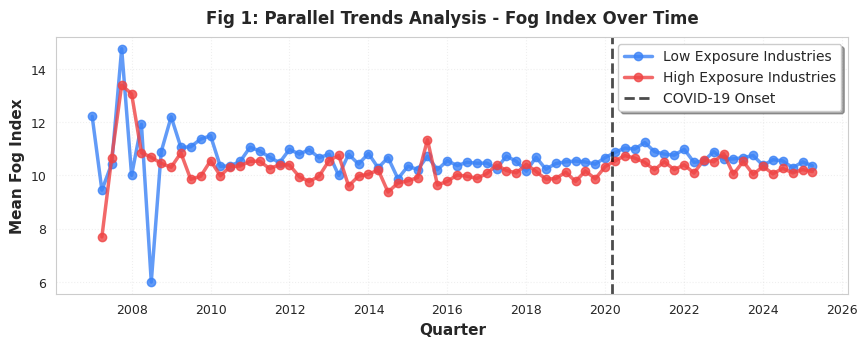

In [18]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
ax1 = fig.add_subplot(gs[0, :2])
time_data = (
    panel[panel["is_balanced"]]
    .groupby(["quarter", "high_exposure"])
    .agg({"fog_index": "mean", "year": "first"})
    .reset_index()
)
time_data["quarter_date"] = time_data["quarter"].dt.to_timestamp()

for exp in [0, 1]:
    data = time_data[time_data["high_exposure"] == exp]
    color = "#ef4444" if exp == 1 else "#3b82f6"
    label = "High Exposure Industries" if exp == 1 else "Low Exposure Industries"
    ax1.plot(data["quarter_date"], data["fog_index"],
             marker='o', linewidth=2.5, markersize=6,
             label=label, color=color, alpha=0.8)

ax1.axvline(pd.Timestamp("2020-03-01"), color='black', linestyle='--',
            linewidth=2, alpha=0.7, label='COVID-19 Onset')
ax1.set_xlabel("Quarter", fontsize=11, fontweight='bold')
ax1.set_ylabel("Mean Fog Index", fontsize=11, fontweight='bold')
ax1.set_title("Fig 1: Parallel Trends Analysis - Fog Index Over Time",
              fontsize=12, fontweight='bold', pad=10)
ax1.legend(loc='best', frameon=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle=':')

**Plot 3: Sector-level changes**

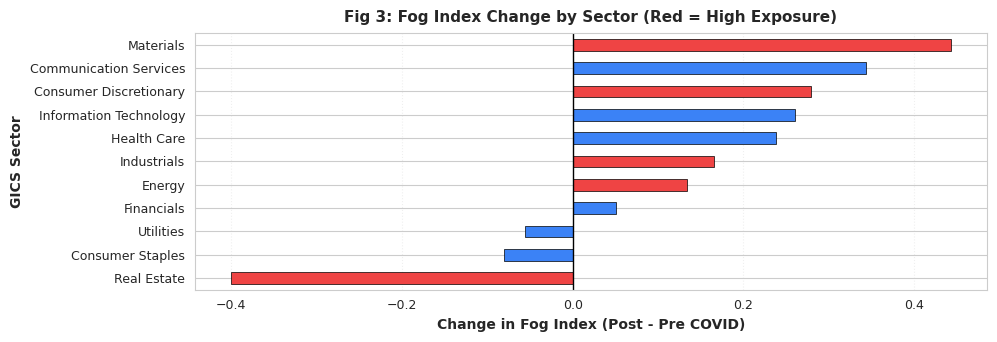

In [49]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
ax3 = fig.add_subplot(gs[1, :2])
sector_changes = (
    panel[panel["is_balanced"]]
    .groupby(["sector_name", "covid"])["fog_index"]
    .mean()
    .unstack())
sector_changes["change"] = sector_changes[1] - sector_changes[0]
sector_changes = sector_changes.sort_values("change")
colors = ['#ef4444' if sector in ["Industrials", "Consumer Discretionary", "Real Estate", "Energy", "Materials"]
          else '#3b82f6' for sector in sector_changes.index]
sector_changes["change"].plot(kind="barh", ax=ax3, color=colors, edgecolor='black', linewidth=0.5)
ax3.axvline(0, color='black', linestyle='-', linewidth=1)
ax3.set_xlabel("Change in Fog Index (Post - Pre COVID)", fontsize=10, fontweight='bold')
ax3.set_ylabel("GICS Sector", fontsize=10, fontweight='bold')
ax3.set_title("Fig 3: Fog Index Change by Sector (Red = High Exposure)",
              fontsize=11, fontweight='bold', pad=8)
ax3.grid(True, alpha=0.3, axis='x', linestyle=':')

**Plot 4: Before/After by exposure**

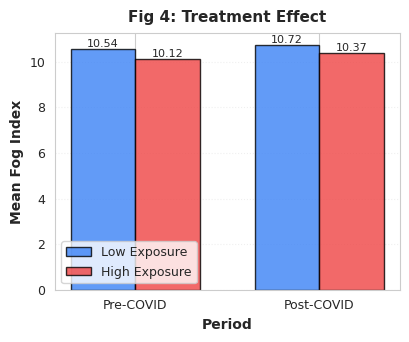

In [21]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
ax4 = fig.add_subplot(gs[1, 2])
means = panel[panel["is_balanced"]].groupby(["high_exposure", "covid"])["fog_index"].mean().unstack()
x = np.arange(2)
width = 0.35
bars1 = ax4.bar(x - width/2, means.loc[0], width,
                label="Low Exposure", color="#3b82f6", alpha=0.8, edgecolor='black')
bars2 = ax4.bar(x + width/2, means.loc[1], width,
                label="High Exposure", color="#ef4444", alpha=0.8, edgecolor='black')
ax4.set_xlabel("Period", fontsize=10, fontweight='bold')
ax4.set_ylabel("Mean Fog Index", fontsize=10, fontweight='bold')
ax4.set_title("Fig 4: Treatment Effect", fontsize=11, fontweight='bold', pad=8)
ax4.set_xticks(x)
ax4.set_xticklabels(["Pre-COVID", "Post-COVID"])
ax4.legend(loc='best', fontsize=9)
ax4.grid(True, alpha=0.3, axis='y', linestyle=':')
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

**Plot 5: Uncertainty vs Fog Index scatter**

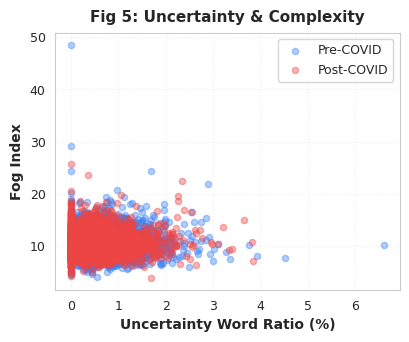

In [22]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
ax5 = fig.add_subplot(gs[2, 0])
pre = panel[panel["covid"]==0]
post = panel[panel["covid"]==1]
ax5.scatter(pre["uncert_ratio"]*100, pre["fog_index"],
           alpha=0.4, s=20, color="#3b82f6", label="Pre-COVID")
ax5.scatter(post["uncert_ratio"]*100, post["fog_index"],
           alpha=0.4, s=20, color="#ef4444", label="Post-COVID")
ax5.set_xlabel("Uncertainty Word Ratio (%)", fontsize=10, fontweight='bold')
ax5.set_ylabel("Fog Index", fontsize=10, fontweight='bold')
ax5.set_title("Fig 5: Uncertainty & Complexity", fontsize=11, fontweight='bold', pad=8)
ax5.legend(loc='best', fontsize=9)
ax5.grid(True, alpha=0.3, linestyle=':')

**Plot 6: Executive characteristics**

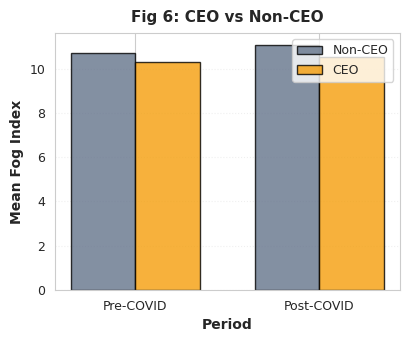

In [23]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
ax6 = fig.add_subplot(gs[2, 1])
exec_data = panel[panel["is_balanced"]].groupby(["is_CEO", "covid"])["fog_index"].mean().unstack()
x = np.arange(2)
width = 0.35
ax6.bar(x - width/2, exec_data.loc[0], width,
        label="Non-CEO", color="#64748b", alpha=0.8, edgecolor='black')
ax6.bar(x + width/2, exec_data.loc[1], width,
        label="CEO", color="#f59e0b", alpha=0.8, edgecolor='black')
ax6.set_xlabel("Period", fontsize=10, fontweight='bold')
ax6.set_ylabel("Mean Fog Index", fontsize=10, fontweight='bold')
ax6.set_title("Fig 6: CEO vs Non-CEO", fontsize=11, fontweight='bold', pad=8)
ax6.set_xticks(x)
ax6.set_xticklabels(["Pre-COVID", "Post-COVID"])
ax6.legend(loc='best', fontsize=9)
ax6.grid(True, alpha=0.3, axis='y', linestyle=':')

**Plot 7: Stock return vs complexity change**

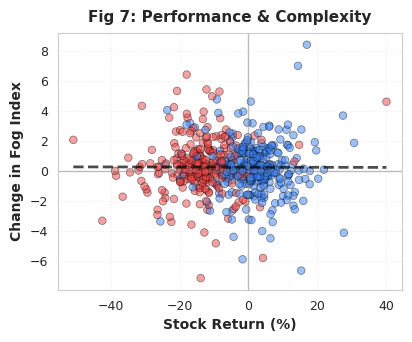

In [24]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
ax7 = fig.add_subplot(gs[2, 2])
firm_changes = panel[panel["is_balanced"]].groupby("gvkey").apply(
    lambda x: pd.Series({
        "fog_change": x[x["covid"]==1]["fog_index"].mean() - x[x["covid"]==0]["fog_index"].mean()
        if x["covid"].nunique() > 1 else np.nan,
        "return": x[x["covid"]==1]["stock_return"].mean()
    })
).dropna()
colors_scatter = ['#ef4444' if gvkey in panel[panel["high_exposure"]==1]["gvkey"].values
                  else '#3b82f6' for gvkey in firm_changes.index]
ax7.scatter(firm_changes["return"]*100, firm_changes["fog_change"],
           alpha=0.5, s=30, c=colors_scatter, edgecolors='black', linewidth=0.5)
z = np.polyfit(firm_changes["return"]*100, firm_changes["fog_change"], 1)
p = np.poly1d(z)
x_line = np.linspace(firm_changes["return"].min()*100, firm_changes["return"].max()*100, 100)
ax7.plot(x_line, p(x_line), "k--", linewidth=2, alpha=0.7)
ax7.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
ax7.axvline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
ax7.set_xlabel("Stock Return (%)", fontsize=10, fontweight='bold')
ax7.set_ylabel("Change in Fog Index", fontsize=10, fontweight='bold')
ax7.set_title("Fig 7: Performance & Complexity", fontsize=11, fontweight='bold', pad=8)
ax7.grid(True, alpha=0.3, linestyle=':')

**Preparing Panel Data for Regression**

In [25]:
panel["quarter_ts"] = panel["quarter"].dt.to_timestamp()
panel_reg = panel.set_index(["gvkey", "quarter_ts"]).sort_index()
reg_vars = [
    "fog_index", "covid", "covid_x_exposure", "high_exposure",
    "neg_ratio", "pos_ratio", "uncert_ratio", "litig_ratio",
    "exec_age", "exec_tenure", "is_CEO", "CEO_Duality",
    "log_duration", "log_views", "stock_return", "volatility", "roa"]
panel_clean = panel_reg.dropna(subset=reg_vars)
print(f"\n✓ Regression sample: {len(panel_clean):,} firm-quarter observations")
print(f"  Firms: {panel_clean.index.get_level_values(0).nunique():,}")
print(f"  Quarters: {panel_clean.index.get_level_values(1).nunique()}")


✓ Regression sample: 9,711 firm-quarter observations
  Firms: 1,101
  Quarters: 74


**MODEL 1: Overall COVID Effect**

In [26]:
print("Specification: fog_index ~ COVID + Controls + α_i")
print("Purpose: Test if communication complexity increased during COVID\n")
X1 = panel_clean[[
    "covid",
    "neg_ratio", "pos_ratio", "uncert_ratio",
    "exec_age", "exec_tenure", "is_CEO",
    "log_duration", "log_views",
    "stock_return", "volatility"]]
model1 = PanelOLS(panel_clean["fog_index"], X1,
                  entity_effects=True,
                  time_effects=False)
results1 = model1.fit(cov_type="clustered", cluster_entity=True)
print(results1)
print("\nKEY FINDING (Model 1):")
print(f"  COVID coefficient: {results1.params['covid']:.4f}")
print(f"  Standard error: {results1.std_errors['covid']:.4f}")
print(f"  T-statistic: {results1.tstats['covid']:.3f}")
print(f"  P-value: {results1.pvalues['covid']:.4f}")
print(f"  95% CI: [{results1.params['covid'] - 1.96*results1.std_errors['covid']:.4f}, "
      f"{results1.params['covid'] + 1.96*results1.std_errors['covid']:.4f}]")
print(f"  Interpretation: Fog Index {'increased' if results1.params['covid'] > 0 else 'decreased'} "
      f"by {abs(results1.params['covid']):.3f} points during COVID")

Specification: fog_index ~ COVID + Controls + α_i
Purpose: Test if communication complexity increased during COVID

                          PanelOLS Estimation Summary                           
Dep. Variable:              fog_index   R-squared:                        0.0426
Estimator:                   PanelOLS   R-squared (Between):             -0.3284
No. Observations:                9711   R-squared (Within):               0.0426
Date:                Wed, Jan 28 2026   R-squared (Overall):             -0.3469
Time:                        18:29:29   Log-likelihood                -1.795e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      34.768
Entities:                        1101   P-value                           0.0000
Avg Obs:                       8.8202   Distribution:                 F(11,8599)
Min Obs:                       1.0000                                     

**MODEL 2: Heterogeneous Treatment Effect**

In [27]:
print("Specification: fog_index ~ COVID + COVID×HighExposure + Controls + α_i")
print("Purpose: Test if effect differs by industry vulnerability\n")
X2 = panel_clean[[
    "covid", "covid_x_exposure",
    "neg_ratio", "pos_ratio", "uncert_ratio",
    "exec_age", "exec_tenure", "is_CEO", "CEO_Duality",
    "log_duration", "log_views",
    "stock_return", "volatility", "roa"]]
model2 = PanelOLS(panel_clean["fog_index"], X2,
                  entity_effects=True,
                  time_effects=False)
results2 = model2.fit(cov_type="clustered", cluster_entity=True)
print(results2)
print("\nKEY FINDINGS (Model 2):")
print(f"  COVID (low-exposure): {results2.params['covid']:.4f} (p={results2.pvalues['covid']:.4f})")
print(f"  Interaction (additional high-exposure): {results2.params['covid_x_exposure']:.4f} "
      f"(p={results2.pvalues['covid_x_exposure']:.4f})")
print(f"  Total high-exposure effect: {results2.params['covid'] + results2.params['covid_x_exposure']:.4f}")
print(f"\n  HYPOTHESIS TEST:")
print(f"  H0: No differential effect by industry exposure (β_interaction = 0)")
print(f"  H1: High-exposure industries show larger increase (β_interaction > 0)")
if results2.pvalues['covid_x_exposure'] < 0.05:
    print(f"  Result: REJECT H0 at 5% level ({'***' if results2.pvalues['covid_x_exposure'] < 0.01 else '**'})")
    print(f"  Conclusion: High-exposure industries showed SIGNIFICANTLY larger increase")
else:
    print(f"  Result: FAIL TO REJECT H0")
    print(f"  Conclusion: No significant differential effect found")

Specification: fog_index ~ COVID + COVID×HighExposure + Controls + α_i
Purpose: Test if effect differs by industry vulnerability

                          PanelOLS Estimation Summary                           
Dep. Variable:              fog_index   R-squared:                        0.0430
Estimator:                   PanelOLS   R-squared (Between):             -0.3239
No. Observations:                9711   R-squared (Within):               0.0430
Date:                Wed, Jan 28 2026   R-squared (Overall):             -0.3429
Time:                        18:29:29   Log-likelihood                -1.795e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      27.619
Entities:                        1101   P-value                           0.0000
Avg Obs:                       8.8202   Distribution:                 F(14,8596)
Min Obs:                       1.0000                       

**MODEL 3: Canonical DiD (Entity + Time Fixed Effects)**

In [28]:
print("Specification: fog_index ~ COVID×HighExposure + Controls + α_i + δ_t")
print("Purpose: Standard difference-in-differences with time FE\n")
X3 = panel_clean[[
    "covid_x_exposure",
    "neg_ratio", "pos_ratio", "uncert_ratio",
    "exec_age", "exec_tenure", "is_CEO", "CEO_Duality",
    "log_duration", "log_views",
    "stock_return", "volatility", "roa"]]
model3 = PanelOLS(panel_clean["fog_index"], X3,
                  entity_effects=True,
                  time_effects=True,
                  drop_absorbed=True)
results3 = model3.fit(cov_type="clustered", cluster_entity=True)
print(results3)
print("\nKEY FINDING (Model 3 - DiD Estimate):")
print(f"  DiD coefficient: {results3.params['covid_x_exposure']:.4f}")
print(f"  P-value: {results3.pvalues['covid_x_exposure']:.4f}")
print(f"  Interpretation: High-exposure industries increased Fog Index by")
print(f"                  {results3.params['covid_x_exposure']:.3f} points MORE than low-exposure")

Specification: fog_index ~ COVID×HighExposure + Controls + α_i + δ_t
Purpose: Standard difference-in-differences with time FE

                          PanelOLS Estimation Summary                           
Dep. Variable:              fog_index   R-squared:                        0.0366
Estimator:                   PanelOLS   R-squared (Between):             -0.2824
No. Observations:                9711   R-squared (Within):               0.0328
Date:                Wed, Jan 28 2026   R-squared (Overall):             -0.3024
Time:                        18:29:31   Log-likelihood                -1.787e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      24.910
Entities:                        1101   P-value                           0.0000
Avg Obs:                       8.8202   Distribution:                 F(13,8524)
Min Obs:                       1.0000                          

**MODEL 4: Balanced Panel Only**

In [29]:
print("Specification: Same as Model 2, but only firms in both periods")
print("Purpose: Address selection bias from unbalanced panel\n")
panel_balanced = panel_reg[panel_reg["is_balanced"]].dropna(subset=reg_vars)
X4 = panel_balanced[[
    "covid", "covid_x_exposure",
    "neg_ratio", "pos_ratio", "uncert_ratio",
    "exec_age", "exec_tenure", "is_CEO", "CEO_Duality",
    "log_duration", "log_views",
    "stock_return", "volatility", "roa"]]
model4 = PanelOLS(panel_balanced["fog_index"], X4,
                  entity_effects=True,
                  time_effects=False)
results4 = model4.fit(cov_type="clustered", cluster_entity=True)
print(results4)
print("\nBALANCED PANEL CHECK:")
print(f"  Interaction coefficient: {results4.params['covid_x_exposure']:.4f}")
print(f"  Comparison to full sample: {results2.params['covid_x_exposure']:.4f}")
print(f"  Difference: {abs(results4.params['covid_x_exposure'] - results2.params['covid_x_exposure']):.4f}")
print(f"  Conclusion: Results are {'robust' if abs(results4.params['covid_x_exposure'] - results2.params['covid_x_exposure']) < 0.1 else 'sensitive'} to sample composition")

Specification: Same as Model 2, but only firms in both periods
Purpose: Address selection bias from unbalanced panel

                          PanelOLS Estimation Summary                           
Dep. Variable:              fog_index   R-squared:                        0.0437
Estimator:                   PanelOLS   R-squared (Between):             -0.3352
No. Observations:                8415   R-squared (Within):               0.0437
Date:                Wed, Jan 28 2026   R-squared (Overall):             -0.3431
Time:                        18:29:31   Log-likelihood                -1.574e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      25.575
Entities:                         562   P-value                           0.0000
Avg Obs:                       14.973   Distribution:                 F(14,7839)
Min Obs:                       2.0000                                   



> ROBUSTNESS CHECKS





**Final Results and Interpretation**

In [37]:
print(f"""

RESEARCH QUESTION:
Did COVID-19 drive executives to adopt more complex communication styles,
and did this vary by industry vulnerability?

MAIN FINDINGS:

1. OVERALL COVID EFFECT (Model 1):
   • Fog Index increased by {results1.params['covid']:.3f} points during COVID
   • Statistical significance: {('***' if results1.pvalues['covid'] < 0.01 else '**' if results1.pvalues['covid'] < 0.05 else '*' if results1.pvalues['covid'] < 0.10 else 'Not significant')}
   • Interpretation: Executives used {'more' if results1.params['covid'] > 0 else 'less'} complex language during the pandemic

2. DIFFERENTIAL EFFECT BY INDUSTRY (Model 2 - KEY RESULT):
   • Low-exposure industries: {results2.params['covid']:.3f} point increase
   • High-exposure industries: {results2.params['covid'] + results2.params['covid_x_exposure']:.3f} point increase
   • Differential effect: {results2.params['covid_x_exposure']:.3f} points
   • P-value for interaction: {results2.pvalues['covid_x_exposure']:.4f}

   HYPOTHESIS TEST:
   H0: No differential effect (β_interaction = 0)
   H1: High-exposure industries show larger increase (β_interaction > 0)

   Decision: {'REJECT H0' if results2.pvalues['covid_x_exposure'] < 0.05 else 'FAIL TO REJECT H0'}

   CONCLUSION: The "Defensive Vagueness" hypothesis is {'SUPPORTED' if results2.pvalues['covid_x_exposure'] < 0.05 and results2.params['covid_x_exposure'] > 0 else 'NOT SUPPORTED'}

   {'High-exposure industries (Travel, Retail, Real Estate, etc.) showed' if results2.pvalues['covid_x_exposure'] < 0.05 and results2.params['covid_x_exposure'] > 0 else 'We do not find that high-exposure industries showed'}
   {'a significantly steeper increase in communication complexity.' if results2.pvalues['covid_x_exposure'] < 0.05 and results2.params['covid_x_exposure'] > 0 else 'significantly different communication patterns.'}

3. ROBUSTNESS:
   • DiD with time FE (Model 3): {results3.params['covid_x_exposure']:.3f} (p={results3.pvalues['covid_x_exposure']:.4f})
   • Balanced panel only
""")



RESEARCH QUESTION:
Did COVID-19 drive executives to adopt more complex communication styles,
and did this vary by industry vulnerability?

MAIN FINDINGS:

1. OVERALL COVID EFFECT (Model 1):
   • Fog Index increased by 0.459 points during COVID
   • Statistical significance: ***
   • Interpretation: Executives used more complex language during the pandemic

2. DIFFERENTIAL EFFECT BY INDUSTRY (Model 2 - KEY RESULT):
   • Low-exposure industries: 0.455 point increase
   • High-exposure industries: 0.460 point increase
   • Differential effect: 0.005 points
   • P-value for interaction: 0.9612

   HYPOTHESIS TEST:
   H0: No differential effect (β_interaction = 0)
   H1: High-exposure industries show larger increase (β_interaction > 0)

   Decision: FAIL TO REJECT H0

   CONCLUSION: The "Defensive Vagueness" hypothesis is NOT SUPPORTED

   We do not find that high-exposure industries showed
   significantly different communication patterns.

3. ROBUSTNESS:
   • DiD with time FE (Model 3):